# Trajectory Generation
Generates random waypoints and interpolates splines for each sampled times. Then episodes are generated by selecting various starting points distributed around the starting point.

In [1]:
import pandas
import h5py
import numpy as np
import shutil
import pathlib
import itertools

from scipy.interpolate import CubicSpline, UnivariateSpline, BivariateSpline
import matplotlib.pyplot as plt

In [2]:
next_waypoint_dist = 0.5 * np.array(
    [3.0, 5.0]
)  # min/max distance from current to next waypoint
next_waypoint_time = np.array([4.0, 5.0])  # min/max time from current to next waypoint
total_time = 30.0  # total time of the whole path
sample_time = 0.1  # sample time of the splines

spline_method = CubicSpline

r = np.random.default_rng(42)  # for reproducibility

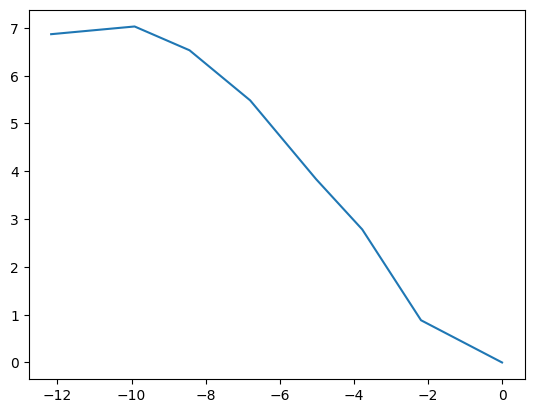

In [3]:
def generate_waypoints(
    next_waypoint_dist,
    next_waypoint_time,
    total_time,
    start_waypoint=np.zeros(2),
    velocity_bias=2.25,
):
    # for convenience
    min_time, max_time = next_waypoint_time
    min_dist, max_dist = next_waypoint_dist

    curr_time = 0.0
    curr_waypoint = np.array(start_waypoint)
    curr_vel = np.zeros(2)

    timestamped_waypoints = [np.asarray([*start_waypoint, 0.0])]
    while curr_time < total_time:
        # clamps traversal time to ensure we don't cross the total time
        traversal_time = min_time + (max_time - min_time) * r.random()
        next_time = np.minimum(curr_time + traversal_time, total_time)

        # gets a random direction vector
        traversal_ang = r.random() * 2 * np.pi
        traversal_dir = np.array([np.cos(traversal_ang), np.sin(traversal_ang)])

        # to prevent a completely randomized path (which reversals will cause
        # sharp and frequent turns for splines) we will carry over some some
        # displacement from the current velocity to act as a bias
        bias = velocity_bias * curr_vel * traversal_time

        traversal_dist = min_dist + (max_dist - min_dist) * r.random()
        traversal_displacement = traversal_dist * traversal_dir + bias

        traversal_displacement = (
            traversal_displacement
            / np.linalg.norm(traversal_displacement)
            * traversal_dist
        )

        next_waypoint = curr_waypoint + traversal_displacement
        timestamped_waypoints.append(np.asarray([*next_waypoint, next_time]))

        # updates
        curr_time = next_time
        curr_waypoint = next_waypoint
        curr_vel = traversal_displacement / traversal_time

    return np.asarray(timestamped_waypoints)


waypoints = generate_waypoints(next_waypoint_dist, next_waypoint_time, total_time)

# plot the generated waypoints
fig, ax = plt.subplots(1, 1)
ax.plot(waypoints[:, 0], waypoints[:, 1])
plt.show()

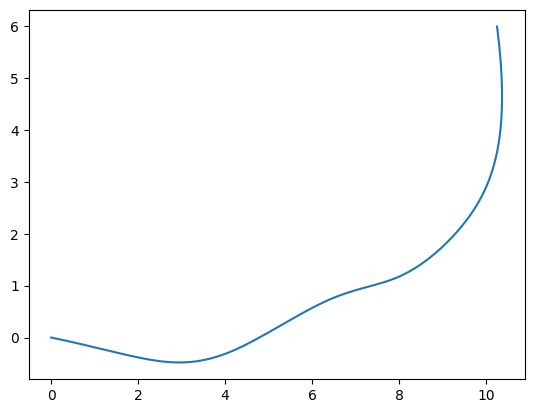

In [4]:
def construct_trajectory(waypoints, dt=0.01, spline_method=CubicSpline):
    max_t = waypoints[-1, 2]
    t = np.arange(0.0, max_t + dt, dt)

    (x_spline, y_spline) = spline_method(
        waypoints[:, 2], waypoints[:, 0]
    ), spline_method(waypoints[:, 2], waypoints[:, 1])

    x_traj, y_traj = x_spline(t), y_spline(t)
    dx_traj, dy_traj = x_spline.derivative()(t), y_spline.derivative()(t)
    ddx_traj, ddy_traj = x_spline.derivative(2)(t), y_spline.derivative(2)(t)

    return t, x_traj, y_traj, dx_traj, dy_traj, ddx_traj, ddy_traj


waypoints = generate_waypoints(next_waypoint_dist, next_waypoint_time, total_time)
_, x_traj, y_traj, _, _, _, _ = construct_trajectory(waypoints, sample_time)

# plot the constructed trajectories
fig, ax = plt.subplots(1, 1)
ax.plot(x_traj, y_traj)
plt.show()

In [5]:
def generate_trajectory(
    next_waypoint_dist,
    next_waypoint_time,
    total_time,
    start_waypoint=np.zeros(2),
    velocity_bias=1.15,
    dt=0.01,
    spline_method=CubicSpline,
):
    waypoints = generate_waypoints(
        next_waypoint_dist,
        next_waypoint_time,
        total_time,
        start_waypoint,
        velocity_bias,
    )
    t, x_traj, y_traj, dx_traj, dy_traj, ddx_traj, ddy_traj = construct_trajectory(
        waypoints, dt, spline_method
    )

    # produces a matrix with a different sample on each row
    return np.stack((t, x_traj, y_traj, dx_traj, dy_traj, ddx_traj, ddy_traj)).T


generate_trajectory(next_waypoint_dist, next_waypoint_time, total_time).shape

(3001, 7)

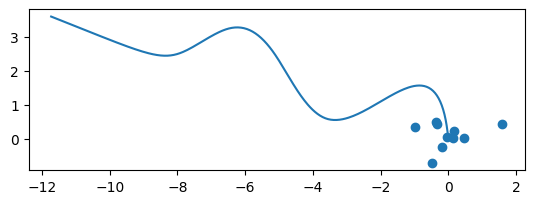

In [6]:
num_trajectories = 20  # number of overall trajectories
num_starting_points = 10  # number of random starting points for each trajectory

start_pos_sigma = 0.25 * np.eye(2)  # distribution of initial positions

# generate a number of trajectories and initial conditions for each trajectory
# and once randomized then we'll store them as training and test data respectively

episodes = []
episode_counter = 0
for i in range(num_trajectories):
    traj_data = generate_trajectory(
        next_waypoint_dist, next_waypoint_time, total_time, dt=sample_time
    )
    traj_start_pos = traj_data[0, 1:3]

    start_positions = r.multivariate_normal(
        traj_start_pos, start_pos_sigma, size=(num_starting_points)
    )

    for j in range(num_starting_points):
        episodes.append((traj_data, start_positions[j, :]))

# plot the last trajectory and all starting positions
fig, ax = plt.subplots(1, 1)
ax.plot(traj_data[:, 1], traj_data[:, 2])
ax.scatter(start_positions[:, 0], start_positions[:, 1])
ax.set_aspect("equal")
plt.show()

In [7]:
train_dir = pathlib.Path("../data/episodes/train")
test_dir = pathlib.Path("../data/episodes/test")

# empty these repositories so we have no issues when writing the episodes that
# were generated in the preceding section
for file in itertools.chain(train_dir.iterdir(), test_dir.iterdir()):
    if file.name == ".gitkeep":
        continue  # don't delete this file
    file.unlink()

num_train = int(len(episodes) * 0.7)  # recommended 70-30 split

# must randomize the order so we don't have a single trajectory in either the
# training or testing data set and we more variety in the training data
# NOTE: by shuffling this way we keep using the seeded randomness from numpy

rand_idx = np.arange(len(episodes))
r.shuffle(rand_idx)

rand_episodes = list(map(lambda idx: episodes[idx], rand_idx))
for i in range(len(episodes)):
    traj, start = rand_episodes[i]

    file = (
        train_dir.joinpath(f"train_{i}.h5")
        if i < num_train
        else test_dir.joinpath(f"test_{i - num_train}.h5")
    )
    with h5py.File(file, "w") as f:
        f.create_dataset("t_traj", data=traj[:, 0])
        f.create_dataset("x_traj", data=traj[:, 1])
        f.create_dataset("y_traj", data=traj[:, 2])
        f.create_dataset("dx_traj", data=traj[:, 3])
        f.create_dataset("dy_traj", data=traj[:, 4])
        f.create_dataset("ddx_traj", data=traj[:, 5])
        f.create_dataset("ddy_traj", data=traj[:, 6])
        f.attrs["sample_time"] = sample_time
        f.attrs["start_pos"] = start